In [2]:
demanda = 250000 # MWh/año

LHV = 33.33 

mH2 = demanda * 1000 / LHV

print("mH2:", mH2)

e_spec = 53

E_elec = mH2 * e_spec / 1000
print("E_elec:", E_elec)

CF_el = 0.6

P_el = E_elec / (8760 * CF_el)
print("P_el:", P_el)

# Calcular P_renovable

m_agua_st = mH2 * 9
print("m_agua_st:", m_agua_st)

f_agua = 12/9

m_agua_real = m_agua_st * f_agua
print("m_agua_real:", m_agua_real)

m_oxigeno = mH2 * 8
print("m_oxigeno:", m_oxigeno)

CF_eolico = 0.326
CF_solar = 0.23

P_eolico = E_elec / (8760 * CF_eolico)
P_solar = E_elec / (8760 * CF_solar)

print("P_eolico:", P_eolico)
print("P_solar:", P_solar)


fraccion_eolica = 0.4
fraccion_solar = 0.6

CF_hibrido = fraccion_eolica * CF_eolico + fraccion_solar * CF_solar

P_hibrida = E_elec / (8760 * CF_hibrido)

print("Factor de planta híbrido:", CF_hibrido)
print("Potencia renovable híbrida:", P_hibrida)

mH2: 7500750.075007501
E_elec: 397539.7539753975
P_el: 75.63541742302084
m_agua_st: 67506750.67506751
m_agua_real: 90009000.90009001
m_oxigeno: 60006000.60006001
P_eolico: 139.20628973562114
P_solar: 197.30978458179345
Factor de planta híbrido: 0.2684
Potencia renovable híbrida: 169.08066488007637


In [3]:
autonomia_h = 24

mH2_dia = mH2 / 365
mH2_hora = mH2_dia / 24

N_aut = autonomia_h / 24

M_alm = mH2_dia * N_aut

print("Consumo diario de H2:", mH2_dia)
print("Consumo horario de H2:",mH2_hora)
print("Almacenamiento mínimo:",M_alm)
print("Almacenamiento mínimo:", M_alm / 1000)

R_H2 = 4124        
T_H2 = 25 + 273.15 

P_manometrica = 30e5  
P_atmosferica = 1e5   
P_absoluta = P_manometrica + P_atmosferica

rho_H2 = P_absoluta / (R_H2 * T_H2)
V_alm = M_alm / rho_H2

print("Densidad ideal del H2:",rho_H2)
print("Volumen aproximado a 30 bar:",V_alm)

Consumo diario de H2: 20550.000205500004
Consumo horario de H2: 856.2500085625002
Almacenamiento mínimo: 20550.000205500004
Almacenamiento mínimo: 20.550000205500005
Densidad ideal del H2: 2.521205370395161
Volumen aproximado a 30 bar: 8150.863252476374


In [4]:
n = 20
i = 0.08

CRF = i * (1 + i)**n / ((1 + i)**n - 1)

CAPEX_spec = 1000  
CAPEX_total = P_el * 1000 * CAPEX_spec 

CAPEX_anualizado = CAPEX_total * CRF  

OPEX_fijo_porcentaje = 0.03
OPEX_variable_unitario = 0.10  

OPEX_fijo = OPEX_fijo_porcentaje * CAPEX_total
OPEX_variable = OPEX_variable_unitario * mH2

c_elec = 60 
C_electricidad = E_elec * c_elec

consumo_agua = 12  
c_agua = 2         

V_agua = mH2 * consumo_agua / 1000 
C_agua = V_agua * c_agua

Costo_produccion = CAPEX_anualizado + OPEX_fijo + OPEX_variable + C_electricidad + C_agua

LCOH_producido = Costo_produccion / mH2


c_acond_pipe = 0.25    
c_transp_pipe = 0.05    
distancia = 15         

C_acondicionamiento = mH2 * c_acond_pipe

C_transporte = mH2 * c_transp_pipe * distancia / 100

Costo_entregado = Costo_produccion+ C_acondicionamiento+ C_transporte


LCOH_entregado = Costo_entregado / mH2

print("CRF:", CRF)
print("CAPEX total:", CAPEX_total)
print("CAPEX anualizado:", CAPEX_anualizado / 1e6)
print("OPEX fijo:", OPEX_fijo / 1e6)
print("OPEX variable:", OPEX_variable / 1e6)
print("Costo electricidad:", C_electricidad / 1e6)
print("Costo agua:", C_agua / 1e6)
print("Costo acondicionamiento:", C_acondicionamiento / 1e6)
print("Costo transporte:", C_transporte / 1e6)
print("LCOH producido:", LCOH_producido)
print("LCOH entregado:", LCOH_entregado)

c_buffer = 0.20  # USD/kg H2

C_buffer = mH2 * c_buffer

LCOH_entregado_buffer = (Costo_entregado + C_buffer) / mH2

print("LCOH entregado con buffer:", LCOH_entregado_buffer)

CRF: 0.10185220882315059
CAPEX total: 75635417.42302084
CAPEX anualizado: 7.703634329795681
OPEX fijo: 2.269062522690625
OPEX variable: 0.7500750075007502
Costo electricidad: 23.852385238523848
Costo agua: 0.18001800180018002
Costo acondicionamiento: 1.8751875187518752
Costo transporte: 0.056255625562556255
LCOH producido: 4.633559944373474
LCOH entregado: 4.891059944373474
LCOH entregado con buffer: 5.091059944373473


LCOH base: 5.091 USD/kg H2
Electricidad anual base: 397.54 GWh/año
Potencia base del electrolizador: 75.64 MW


,Variable,Escenario,Valor,Unidad,LCOH (USD/kg H2),Variación LCOH (%)
0,Precio de electricidad,Mínimo,30.000,USD/MWh,3.501,-31.23%
1,Precio de electricidad,Base,60.000,USD/MWh,5.091,+0.00%
2,Precio de electricidad,Máximo,100.000,USD/MWh,7.211,+41.64%
3,CAPEX específico,Mínimo,700.000,USD/kW,4.692,-7.83%
4,CAPEX específico,Base,"1,000.000",USD/kW,5.091,+0.00%
5,CAPEX específico,Máximo,"1,400.000",USD/kW,5.623,+10.45%
6,Consumo específico,Mínimo,49.000,kWh/kg H2,4.751,-6.69%
7,Consumo específico,Base,53.000,kWh/kg H2,5.091,+0.00%
8,Consumo específico,Máximo,58.000,kWh/kg H2,5.516,+8.36%
9,Factor de utilización del electrolizador,Mínimo,0.350,fracción,6.041,+18.65%


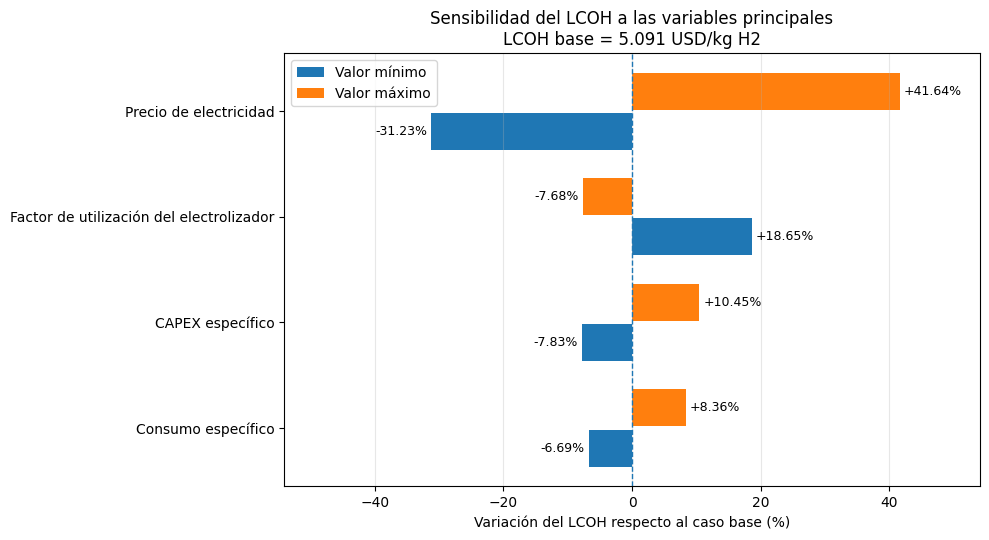

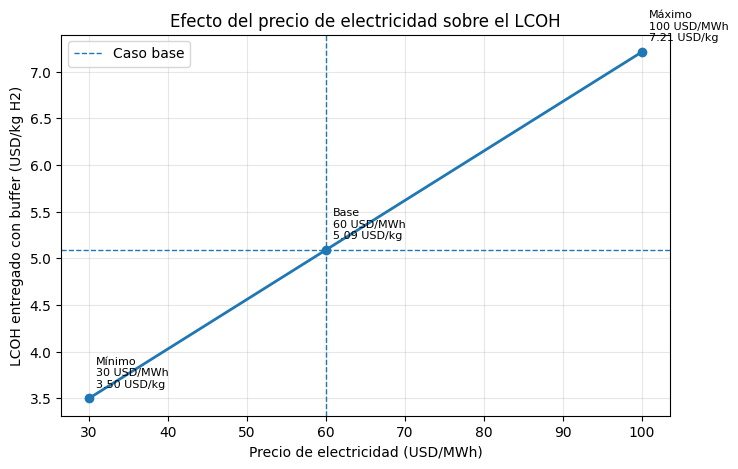

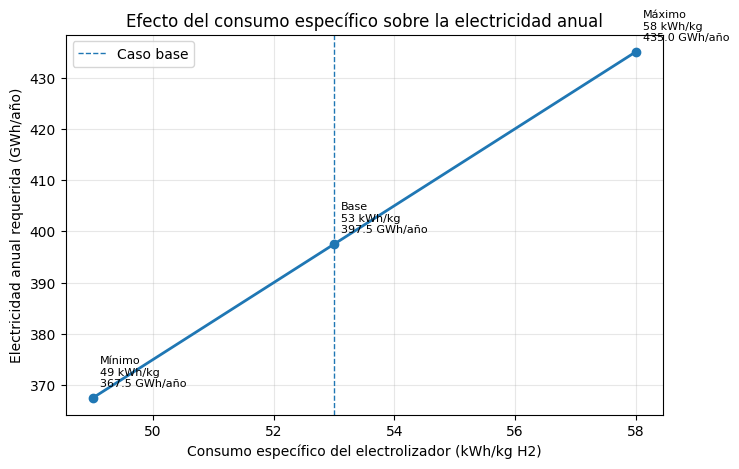

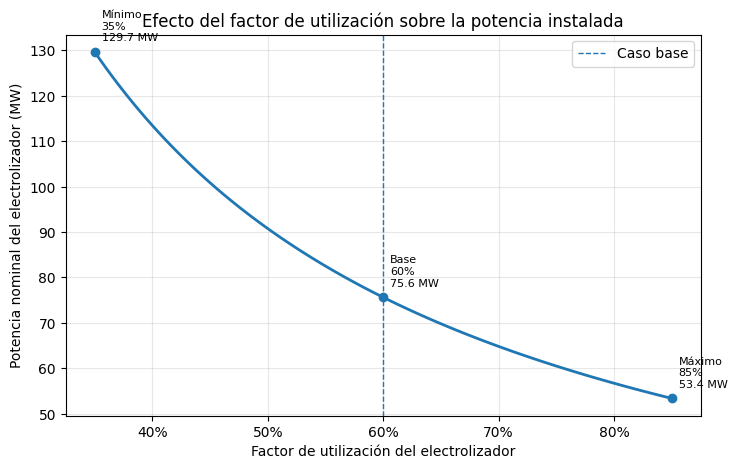

Variable dominante: Precio de electricidad
Variación usando el valor mínimo: -31.23%
Variación usando el valor máximo: +41.64%
Máxima variación absoluta: 41.64%


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display


demanda_sens = 250000         
LHV_sens = 33.33              
mH2_sens = demanda_sens * 1000 / LHV_sens

distancia_sens = 15            # km
CF_hibrido_sens = 0.2684       # 60 % solar y 40 % eólico

n_sens = 20                    # años
i_sens = 0.08                  # tasa de descuento real

CRF_sens = (
    i_sens * (1 + i_sens)**n_sens
    / ((1 + i_sens)**n_sens - 1)
)



parametros_base = {
    "c_elec": 60,                       # USD/MWh
    "CAPEX_spec": 1000,                 # USD/kW
    "OPEX_fijo_porcentaje": 0.03,       # fracción CAPEX/año
    "OPEX_variable_unitario": 0.10,     # USD/kg H2
    "e_spec": 53,                       # kWh/kg H2
    "CF_el": 0.60,                      # fracción
    "consumo_agua": 12,                 # L agua/kg H2
    "c_agua": 2,                        # USD/m3
    "c_acond_pipe": 0.25,               # USD/kg H2
    "c_buffer": 0.20,                   # USD/kg H2
    "c_transp_pipe": 0.05               # USD/kg H2 por 100 km
}


rangos = {
    "Precio de electricidad": {
        "parametro": "c_elec",
        "valores": [30, 60, 100],
        "unidad_variable": "USD/MWh",
        "resultado_grafico": "LCOH_entregado_buffer",
        "unidad_resultado": "USD/kg H2"
    },

    "CAPEX específico": {
        "parametro": "CAPEX_spec",
        "valores": [700, 1000, 1400],
        "unidad_variable": "USD/kW",
        "resultado_grafico": "LCOH_entregado_buffer",
        "unidad_resultado": "USD/kg H2"
    },

    "OPEX fijo anual": {
        "parametro": "OPEX_fijo_porcentaje",
        "valores": [0.02, 0.03, 0.05],
        "unidad_variable": "fracción CAPEX/año",
        "resultado_grafico": "LCOH_entregado_buffer",
        "unidad_resultado": "USD/kg H2"
    },

    "OPEX variable": {
        "parametro": "OPEX_variable_unitario",
        "valores": [0.05, 0.10, 0.20],
        "unidad_variable": "USD/kg H2",
        "resultado_grafico": "LCOH_entregado_buffer",
        "unidad_resultado": "USD/kg H2"
    },

    "Consumo específico": {
        "parametro": "e_spec",
        "valores": [49, 53, 58],
        "unidad_variable": "kWh/kg H2",
        "resultado_grafico": "LCOH_entregado_buffer",
        "unidad_resultado": "USD/kg H2"
    },

    "Factor de utilización del electrolizador": {
        "parametro": "CF_el",
        "valores": [0.35, 0.60, 0.85],
        "unidad_variable": "fracción",
        "resultado_grafico": "P_el_MW",
        "unidad_resultado": "MW"
    },

    "Consumo real de agua": {
        "parametro": "consumo_agua",
        "valores": [10, 12, 15],
        "unidad_variable": "L/kg H2",
        "resultado_grafico": "Agua_m3_año",
        "unidad_resultado": "m3/año"
    },

    "Costo del agua": {
        "parametro": "c_agua",
        "valores": [1, 2, 4],
        "unidad_variable": "USD/m3",
        "resultado_grafico": "LCOH_entregado_buffer",
        "unidad_resultado": "USD/kg H2"
    },

    "Acondicionamiento para ducto": {
        "parametro": "c_acond_pipe",
        "valores": [0.10, 0.25, 0.60],
        "unidad_variable": "USD/kg H2",
        "resultado_grafico": "LCOH_entregado_buffer",
        "unidad_resultado": "USD/kg H2"
    },

    "Buffer local comprimido": {
        "parametro": "c_buffer",
        "valores": [0.08, 0.20, 0.40],
        "unidad_variable": "USD/kg H2",
        "resultado_grafico": "LCOH_entregado_buffer",
        "unidad_resultado": "USD/kg H2"
    },

    "Transporte por ducto": {
        "parametro": "c_transp_pipe",
        "valores": [0.02, 0.05, 0.15],
        "unidad_variable": "USD/kg H2 por 100 km",
        "resultado_grafico": "LCOH_entregado_buffer",
        "unidad_resultado": "USD/kg H2"
    }
}



variables_principales = [
    "Precio de electricidad",
    "CAPEX específico",
    "Consumo específico",
    "Factor de utilización del electrolizador"
]


parametros_base = {
    "demanda": demanda_sens,
    "LHV": LHV_sens,
    "n": n_sens,
    "i": i_sens,
    "distancia": distancia_sens
}

for configuracion in rangos.values():

    parametro = configuracion["parametro"]
    valor_base = configuracion["valores"][1]

    parametros_base[parametro] = valor_base



def calcular_escenario(cambios=None):

    p = parametros_base.copy()

    if cambios is not None:
        p.update(cambios)

    mH2_esc = (
        p["demanda"] * 1000 / p["LHV"]
    )  # kg H2/año

    E_elec_esc = (
        mH2_esc * p["e_spec"] / 1000
    )  # MWh/año


    P_el_esc = (
        E_elec_esc
        / (8760 * p["CF_el"])
    )  # MW


    Agua_esc = (
        mH2_esc * p["consumo_agua"] / 1000
    )  # m3/año


    CRF_esc = (
        p["i"] * (1 + p["i"])**p["n"]
        / ((1 + p["i"])**p["n"] - 1)
    )


    CAPEX_EL_esc = (
        P_el_esc
        * 1000
        * p["CAPEX_spec"]
    )  # USD

    CAPEX_anualizado_esc = (
        CAPEX_EL_esc * CRF_esc
    )  # USD/año


    OPEX_fijo_esc = (
        p["OPEX_fijo_porcentaje"]
        * CAPEX_EL_esc
    )  # USD/año

    OPEX_variable_esc = (
        p["OPEX_variable_unitario"]
        * mH2_esc
    )  # USD/año


    C_electricidad_esc = (
        E_elec_esc * p["c_elec"]
    )  # USD/año

    C_agua_esc = (
        Agua_esc * p["c_agua"]
    )  # USD/año

    C_acondicionamiento_esc = (
        mH2_esc * p["c_acond_pipe"]
    )  # USD/año

    C_transporte_esc = (
        mH2_esc
        * p["c_transp_pipe"]
        * p["distancia"]
        / 100
    )  # USD/año

    C_buffer_esc = (
        mH2_esc * p["c_buffer"]
    )  # USD/año


    Costo_total_esc = (
        CAPEX_anualizado_esc
        + OPEX_fijo_esc
        + OPEX_variable_esc
        + C_electricidad_esc
        + C_agua_esc
        + C_acondicionamiento_esc
        + C_transporte_esc
        + C_buffer_esc
    )

    LCOH_esc = (
        Costo_total_esc / mH2_esc
    )  # USD/kg H2

    return {
        "mH2_t_año": mH2_esc / 1000,
        "E_elec_MWh_año": E_elec_esc,
        "E_elec_GWh_año": E_elec_esc / 1000,
        "P_el_MW": P_el_esc,
        "Agua_m3_año": Agua_esc,
        "CAPEX_EL_USD": CAPEX_EL_esc,
        "CAPEX_EL_MUSD": CAPEX_EL_esc / 1e6,
        "Costo_electricidad_USD_año": C_electricidad_esc,
        "LCOH_entregado_buffer": LCOH_esc
    }



resultado_base = calcular_escenario()

LCOH_base = resultado_base[
    "LCOH_entregado_buffer"
]

print(
    f"LCOH base: {LCOH_base:.3f} USD/kg H2"
)

print(
    f"Electricidad anual base: "
    f"{resultado_base['E_elec_GWh_año']:.2f} GWh/año"
)

print(
    f"Potencia base del electrolizador: "
    f"{resultado_base['P_el_MW']:.2f} MW"
)



filas_todos_escenarios = []

nombres_escenarios = [
    "Mínimo",
    "Base",
    "Máximo"
]

for nombre_variable, configuracion in rangos.items():

    parametro = configuracion["parametro"]
    valores = configuracion["valores"]

    for nombre_escenario, valor in zip(
        nombres_escenarios,
        valores
    ):

        resultado = calcular_escenario({
            parametro: valor
        })

        variacion_LCOH = (
            (
                resultado["LCOH_entregado_buffer"]
                - LCOH_base
            )
            / LCOH_base
            * 100
        )

        filas_todos_escenarios.append({
            "Variable": nombre_variable,
            "Parámetro": parametro,
            "Escenario": nombre_escenario,
            "Valor": valor,
            "Unidad": configuracion["unidad_variable"],
            "LCOH (USD/kg H2)":
                resultado["LCOH_entregado_buffer"],
            "Variación LCOH (%)":
                variacion_LCOH,
            "Electricidad anual (GWh/año)":
                resultado["E_elec_GWh_año"],
            "Potencia electrolizador (MW)":
                resultado["P_el_MW"],
            "Agua (m3/año)":
                resultado["Agua_m3_año"]
        })


df_todos_escenarios = pd.DataFrame(
    filas_todos_escenarios
)


df_resumen_principales = (
    df_todos_escenarios[
        df_todos_escenarios["Variable"].isin(
            variables_principales
        )
    ]
    .copy()
)


df_resumen_principales["Variable"] = pd.Categorical(
    df_resumen_principales["Variable"],
    categories=variables_principales,
    ordered=True
)

df_resumen_principales["Escenario"] = pd.Categorical(
    df_resumen_principales["Escenario"],
    categories=["Mínimo", "Base", "Máximo"],
    ordered=True
)

df_resumen_principales = (
    df_resumen_principales
    .sort_values([
        "Variable",
        "Escenario"
    ])
    .reset_index(drop=True)
)


columnas_resumen = [
    "Variable",
    "Escenario",
    "Valor",
    "Unidad",
    "LCOH (USD/kg H2)",
    "Variación LCOH (%)"
]


tabla_resumen = df_resumen_principales[
    columnas_resumen
].copy()


tabla_resumen["Valor"] = tabla_resumen["Valor"].map(
    lambda x: f"{x:,.3f}"
)

tabla_resumen["LCOH (USD/kg H2)"] = tabla_resumen[
    "LCOH (USD/kg H2)"
].map(
    lambda x: f"{x:,.3f}"
)

tabla_resumen["Variación LCOH (%)"] = tabla_resumen[
    "Variación LCOH (%)"
].map(
    lambda x: f"{x:+.2f}%"
)

display(
    tabla_resumen.reset_index(drop=True)
)


df_tornado = (
    df_resumen_principales[
        df_resumen_principales["Escenario"].isin([
            "Mínimo",
            "Máximo"
        ])
    ]
    .pivot(
        index="Variable",
        columns="Escenario",
        values="Variación LCOH (%)"
    )
    .reset_index()
)

df_tornado["Impacto máximo absoluto"] = (
    df_tornado[[
        "Mínimo",
        "Máximo"
    ]]
    .abs()
    .max(axis=1)
)


df_tornado = (
    df_tornado
    .sort_values(
        "Impacto máximo absoluto",
        ascending=True
    )
    .reset_index(drop=True)
)


y = np.arange(
    len(df_tornado)
)

separacion = 0.19

fig, ax = plt.subplots(
    figsize=(10, 5.5)
)

barras_min = ax.barh(
    y - separacion,
    df_tornado["Mínimo"],
    height=0.35,
    label="Valor mínimo"
)

barras_max = ax.barh(
    y + separacion,
    df_tornado["Máximo"],
    height=0.35,
    label="Valor máximo"
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_yticks(y)

ax.set_yticklabels(
    df_tornado["Variable"]
)

ax.set_xlabel(
    "Variación del LCOH respecto al caso base (%)"
)

ax.set_title(
    "Sensibilidad del LCOH a las variables principales\n"
    f"LCOH base = {LCOH_base:.3f} USD/kg H2"
)

ax.legend()

ax.grid(
    axis="x",
    alpha=0.3
)


ax.bar_label(
    barras_min,
    labels=[
        f"{valor:+.2f}%"
        for valor in df_tornado["Mínimo"]
    ],
    padding=3,
    fontsize=9
)

ax.bar_label(
    barras_max,
    labels=[
        f"{valor:+.2f}%"
        for valor in df_tornado["Máximo"]
    ],
    padding=3,
    fontsize=9
)


limite_tornado = max(
    df_tornado["Impacto máximo absoluto"].max()
    * 1.30,
    1
)

ax.set_xlim(
    -limite_tornado,
    limite_tornado
)

plt.tight_layout()
plt.show()

config_precio = rangos[
    "Precio de electricidad"
]

precio_min, precio_base, precio_max = (
    config_precio["valores"]
)

precios = np.linspace(
    precio_min,
    precio_max,
    100
)

LCOH_precios = [
    calcular_escenario({
        "c_elec": precio
    })["LCOH_entregado_buffer"]
    for precio in precios
]

puntos_precio = np.array([
    precio_min,
    precio_base,
    precio_max
])

puntos_LCOH_precio = [
    calcular_escenario({
        "c_elec": precio
    })["LCOH_entregado_buffer"]
    for precio in puntos_precio
]


plt.figure(
    figsize=(7.5, 4.8)
)

plt.plot(
    precios,
    LCOH_precios,
    linewidth=2
)

plt.scatter(
    puntos_precio,
    puntos_LCOH_precio,
    zorder=3
)

plt.axvline(
    precio_base,
    linestyle="--",
    linewidth=1,
    label="Caso base"
)

plt.axhline(
    LCOH_base,
    linestyle="--",
    linewidth=1
)

for nombre, x, y_valor in zip(
    ["Mínimo", "Base", "Máximo"],
    puntos_precio,
    puntos_LCOH_precio
):

    plt.annotate(
        f"{nombre}\n{x:.0f} USD/MWh\n"
        f"{y_valor:.2f} USD/kg",
        xy=(x, y_valor),
        xytext=(5, 8),
        textcoords="offset points",
        fontsize=8
    )


plt.xlabel(
    "Precio de electricidad (USD/MWh)"
)

plt.ylabel(
    "LCOH entregado con buffer (USD/kg H2)"
)

plt.title(
    "Efecto del precio de electricidad sobre el LCOH"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


config_consumo = rangos[
    "Consumo específico"
]

consumo_min, consumo_base, consumo_max = (
    config_consumo["valores"]
)

consumos = np.linspace(
    consumo_min,
    consumo_max,
    100
)

electricidad_anual = [
    calcular_escenario({
        "e_spec": consumo
    })["E_elec_GWh_año"]
    for consumo in consumos
]

puntos_consumo = np.array([
    consumo_min,
    consumo_base,
    consumo_max
])

puntos_electricidad = [
    calcular_escenario({
        "e_spec": consumo
    })["E_elec_GWh_año"]
    for consumo in puntos_consumo
]


plt.figure(
    figsize=(7.5, 4.8)
)

plt.plot(
    consumos,
    electricidad_anual,
    linewidth=2
)

plt.scatter(
    puntos_consumo,
    puntos_electricidad,
    zorder=3
)

plt.axvline(
    consumo_base,
    linestyle="--",
    linewidth=1,
    label="Caso base"
)

for nombre, x, y_valor in zip(
    ["Mínimo", "Base", "Máximo"],
    puntos_consumo,
    puntos_electricidad
):

    plt.annotate(
        f"{nombre}\n{x:.0f} kWh/kg\n"
        f"{y_valor:.1f} GWh/año",
        xy=(x, y_valor),
        xytext=(5, 8),
        textcoords="offset points",
        fontsize=8
    )


plt.xlabel(
    "Consumo específico del electrolizador (kWh/kg H2)"
)

plt.ylabel(
    "Electricidad anual requerida (GWh/año)"
)

plt.title(
    "Efecto del consumo específico sobre la electricidad anual"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


config_CF = rangos[
    "Factor de utilización del electrolizador"
]

CF_min, CF_base, CF_max = (
    config_CF["valores"]
)

factores_utilizacion = np.linspace(
    CF_min,
    CF_max,
    100
)

potencias = [
    calcular_escenario({
        "CF_el": factor
    })["P_el_MW"]
    for factor in factores_utilizacion
]

puntos_CF = np.array([
    CF_min,
    CF_base,
    CF_max
])

puntos_potencia = [
    calcular_escenario({
        "CF_el": factor
    })["P_el_MW"]
    for factor in puntos_CF
]


fig, ax = plt.subplots(
    figsize=(7.5, 4.8)
)

ax.plot(
    factores_utilizacion,
    potencias,
    linewidth=2
)

ax.scatter(
    puntos_CF,
    puntos_potencia,
    zorder=3
)

ax.axvline(
    CF_base,
    linestyle="--",
    linewidth=1,
    label="Caso base"
)

for nombre, x, y_valor in zip(
    ["Mínimo", "Base", "Máximo"],
    puntos_CF,
    puntos_potencia
):

    ax.annotate(
        f"{nombre}\n{x * 100:.0f}%\n"
        f"{y_valor:.1f} MW",
        xy=(x, y_valor),
        xytext=(5, 8),
        textcoords="offset points",
        fontsize=8
    )


ax.xaxis.set_major_formatter(
    PercentFormatter(xmax=1)
)

ax.set_xlabel(
    "Factor de utilización del electrolizador"
)

ax.set_ylabel(
    "Potencia nominal del electrolizador (MW)"
)

ax.set_title(
    "Efecto del factor de utilización sobre la potencia instalada"
)

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


fila_dominante = df_tornado.loc[
    df_tornado[
        "Impacto máximo absoluto"
    ].idxmax()
]

print(
    "Variable dominante:",
    fila_dominante["Variable"]
)

print(
    "Variación usando el valor mínimo:",
    f"{fila_dominante['Mínimo']:+.2f}%"
)

print(
    "Variación usando el valor máximo:",
    f"{fila_dominante['Máximo']:+.2f}%"
)

print(
    "Máxima variación absoluta:",
    f"{fila_dominante['Impacto máximo absoluto']:.2f}%"
)